Pre defining before going into the Shor Code, is the 3 bit repetition code
Where we have in mind encoding a qubit where standard basis is repeated 3 times
\alpha|0> + \beta|1> \rarrow \alpha|000> + \beta|111>


The 3 bit repetition code is a form of error analysis for a binary symmetric channel, where there is a probabibilty p for a bit flip to occur and probabibility 1 - p that the reciever gets the correct bit that the sender wanted to send. 

What we can do is encode our bit in the 3 bit repetition code. But now we are 3 times more likely to see a error in bit flip. but if at most one bit flip occurs we are able to correct it! So an error therefore exists after decoding if 2 or more bits flip during transmission. 
The probability that 2 or more bits flip during the transmisson phase is, 3p^2(1-p) + p^3. 
Now this is only a good thing if p< 1/2. if p is greater than a half, this will actually increase the likely of error. 


In [2]:
# Qiskit imports
from qiskit import (
    QuantumCircuit,
    QuantumRegister,
    ClassicalRegister,
)
from qiskit_ibm_runtime.circuit import MidCircuitMeasure

import numpy as np 
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# Use a local simulator backend to run the circuit.
backend = FakeFez()

# To run on actual quantum hardware, do this instead (requires an IBM account and an API-key set up):
#service = QiskitRuntimeService()
#backend = service.least_busy(simulator=False, operational=True)



 

ModuleNotFoundError: No module named 'qiskit_ibm_runtime'

In [ ]:
qreg_data = QuantumRegister(3)
qreg_measure = QuantumRegister(2)
creg_data = ClassicalRegister(3, name="data")
creg_syndrome = ClassicalRegister(2, name="syndrome")
state_data = qreg_data[0]
ancillas_data = qreg_data[1:]


def build_qc():
    return QuantumCircuit(qreg_data, qreg_measure, creg_data, creg_syndrome)

reg = build_qc()


def cx_encode(circuit, state, ancillas):
    circuit.x(state)
    circuit.barrier(qreg_data, label= "Initialising State")

    
    for ancilla in ancillas:
        circuit.cx(qreg_data[0], ancilla)
    circuit.barrier(qreg_data, label="Encoded qubits")

    return circuit


So now we have successfully encoded out qubit into a 3 bit repition code. But how can we go through with error analysis?

In [ ]:
def syndrome_measure(Circuit: QuantumCircuit):
    Circuit.cx(qreg_data[0],qreg_measure[0])
    Circuit.cx(qreg_data[1],qreg_measure[0])
    Circuit.cx(qreg_data[1],qreg_measure[1])
    Circuit.cx(qreg_data[2],qreg_measure[1])

    Circuit.barrier(*qreg_data, *qreg_measure)
    """    
    MidCircuitMeasure Is a IBM Runtime-specfic instruction, not universally recognised by statevectors simulations most AER backends etc...
        Circuit.append(MidCircuitMeasure(), [qreg_measure[0]], [creg_syndrome[0]])
        Circuit.append(MidCircuitMeasure(), [qreg_measure[1]], [creg_syndrome[1]])
    """
    
    Circuit.measure(qreg_measure, creg_syndrome)

    with Circuit.if_test((creg_syndrome[0], 1)):
        Circuit.x(qreg_measure[0])
    with Circuit.if_test((creg_syndrome[1], 1)):
        Circuit.x(qreg_measure[1])
    Circuit.barrier(*qreg_data, *qreg_measure)
    
    return Circuit

  




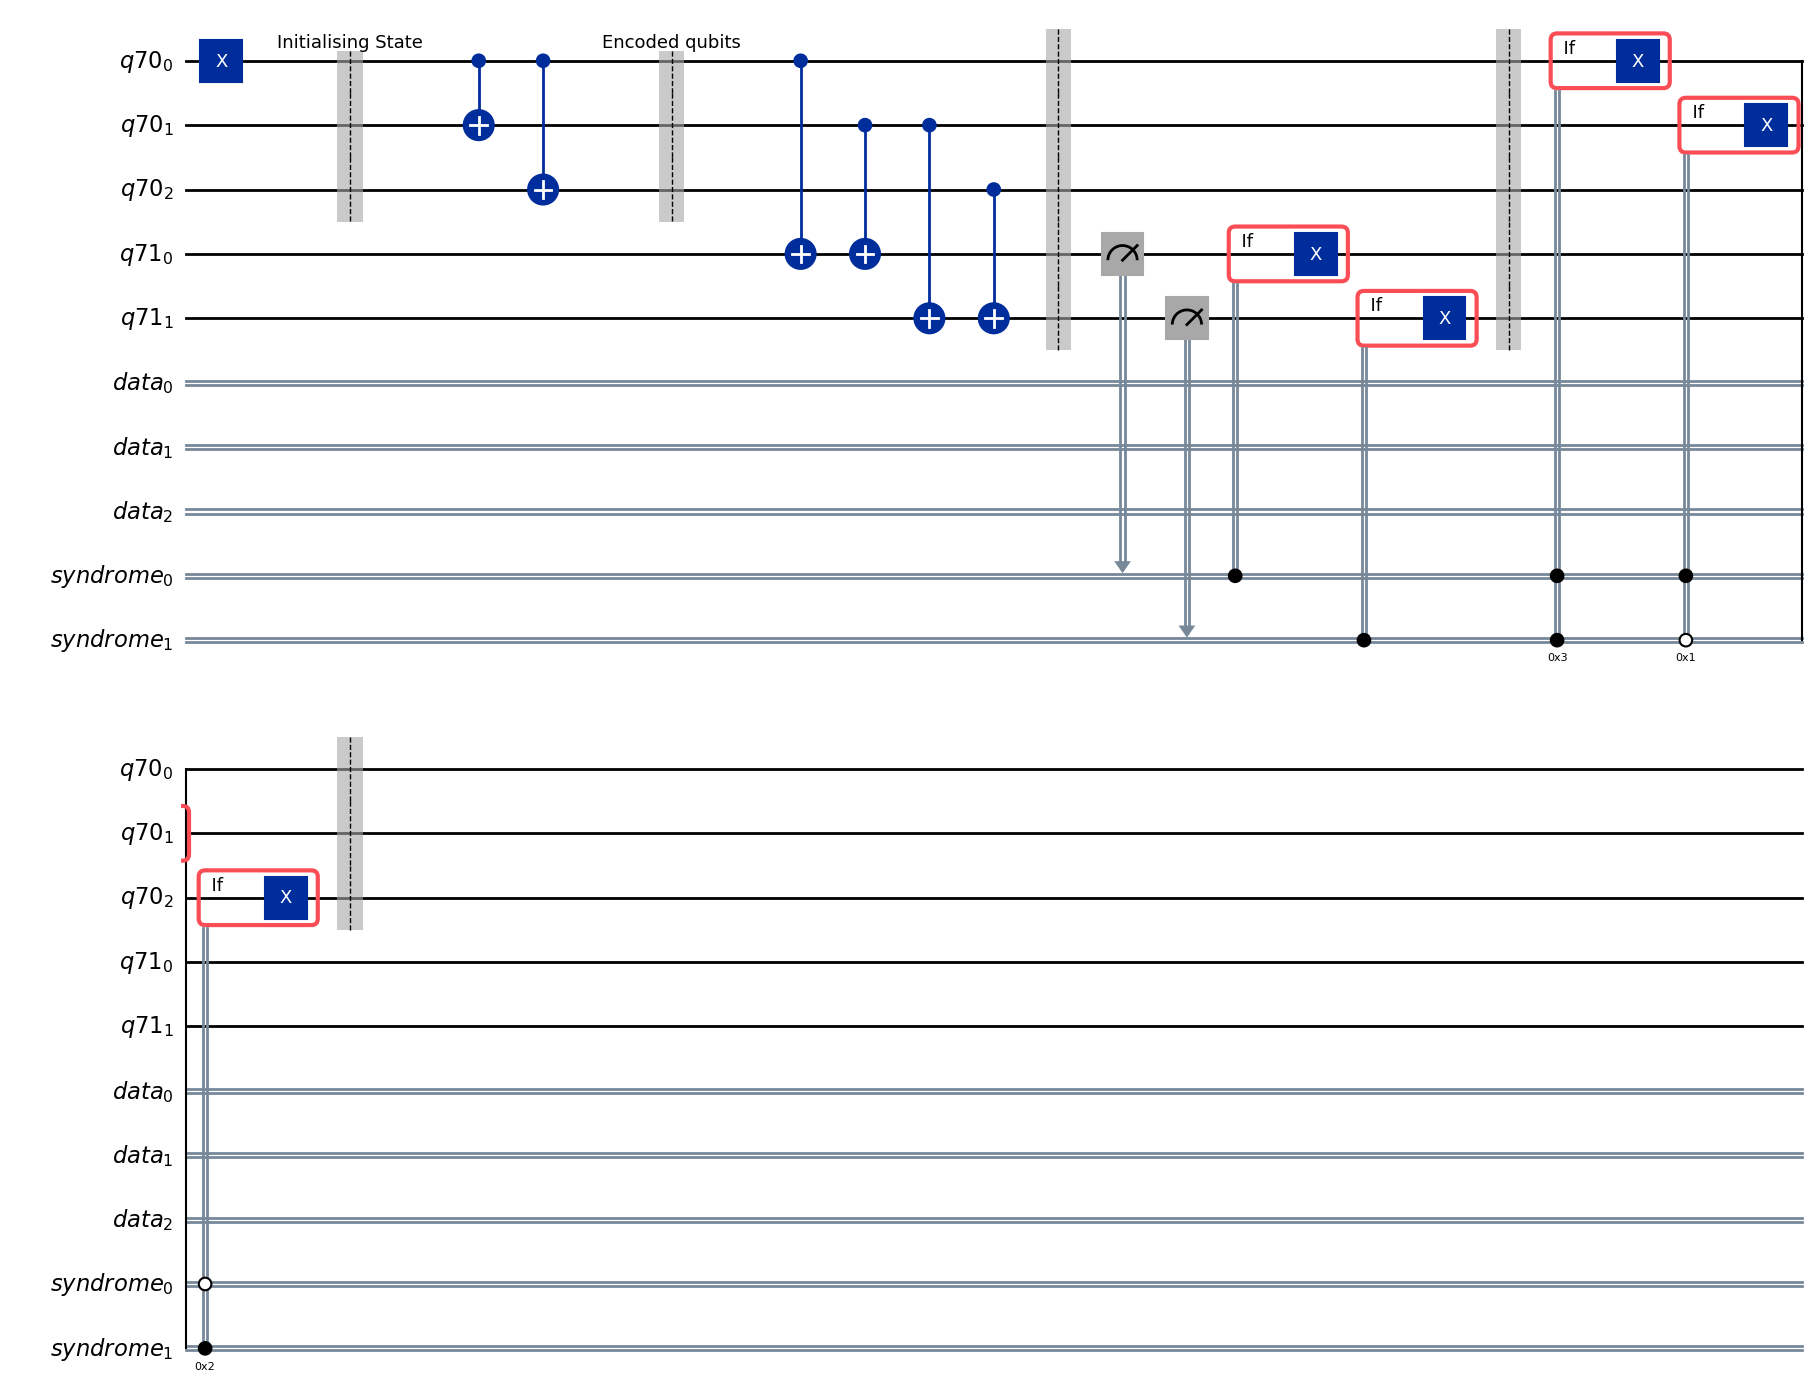

In [ ]:
def Correction_protocol(circuit: QuantumCircuit):
    with circuit.if_test((creg_syndrome, 3)):
        circuit.x(qreg_data[0])
    with circuit.if_test((creg_syndrome, 1)):
        circuit.x(qreg_data[1])
    with circuit.if_test((creg_syndrome, 2)):
        circuit.x(qreg_data[2])
    circuit.barrier(qreg_data)
    return circuit


def build_circuit(apply_correction: bool):
    circuit = build_qc()
    circuit = cx_encode(circuit, state_data, ancillas_data)
    circuit = syndrome_measure(circuit)
    if apply_correction:
        circuit = Correction_protocol(circuit)

    return circuit

circuit = build_circuit(True)
circuit.draw(output="mpl", style="iqp", cregbundle=False)

So Now we have encoded to check for bit flip errors and fix those errors by placing the X gate on the Corresponding Qubit, However that is not the only thing that we have to worry about, We also concern ourselves with Phase-flip errors. which are described by the Z gate. The 3 bit repetition code is completely oblivious to these kind of errors, So how can we modify the above to detect and correct these phase flip and bit flip errors? Well that will maybe be what the Shor code will be useful for... But lets see how we can correct phase flip errors only and THEN try and combine the two methods


We will start off with a similar starting point, but instead we shall change our basis to the |+> and |->, after encoding our state into 3 logical bits

In [ ]:
qreg_data = QuantumRegister(3)
qreg_measure = QuantumRegister(2)
creg_data = ClassicalRegister(3, name="data")
creg_syndrome = ClassicalRegister(2, name="syndrome")
state_data = qreg_data[0]
ancillas_data = qreg_data[1:]


def build_qc():
    return QuantumCircuit(qreg_data, qreg_measure, creg_data, creg_syndrome)


def cx_encode(circuit, state, ancillas):    
    
    circuit.barrier(qreg_data, label= "Initialising State")
    for ancilla in ancillas:
        circuit.cx(qreg_data[0], ancilla)
    circuit.barrier(qreg_data, label="Encoded qubits")
    for i in qreg_data:
        circuit.h(i)
    circuit.barrier(qreg_data, label= "Changing from |0> to |+>")

    
    return circuit




In [ ]:
def measure(circuit):
    for i in qreg_measure:
        circuit.h(i)
    
    circuit.cx(qreg_measure[0], qreg_data[0])
    circuit.cx(qreg_measure[0], qreg_data[1])
    circuit.cx(qreg_measure[1], qreg_data[1])
    circuit.cx(qreg_measure[1], qreg_data[2])
    circuit.barrier(qreg_data, qreg_measure)


    for i in qreg_measure:
        circuit.h(i)

    circuit.measure(qreg_measure, creg_syndrome)


    with circuit.if_test((creg_syndrome[0], 1)):
        circuit.x(qreg_measure[0])
    with circuit.if_test((creg_syndrome[1], 1)):
        circuit.x(qreg_measure[1])
    circuit.barrier(*qreg_data, *qreg_measure)

    return circuit


    

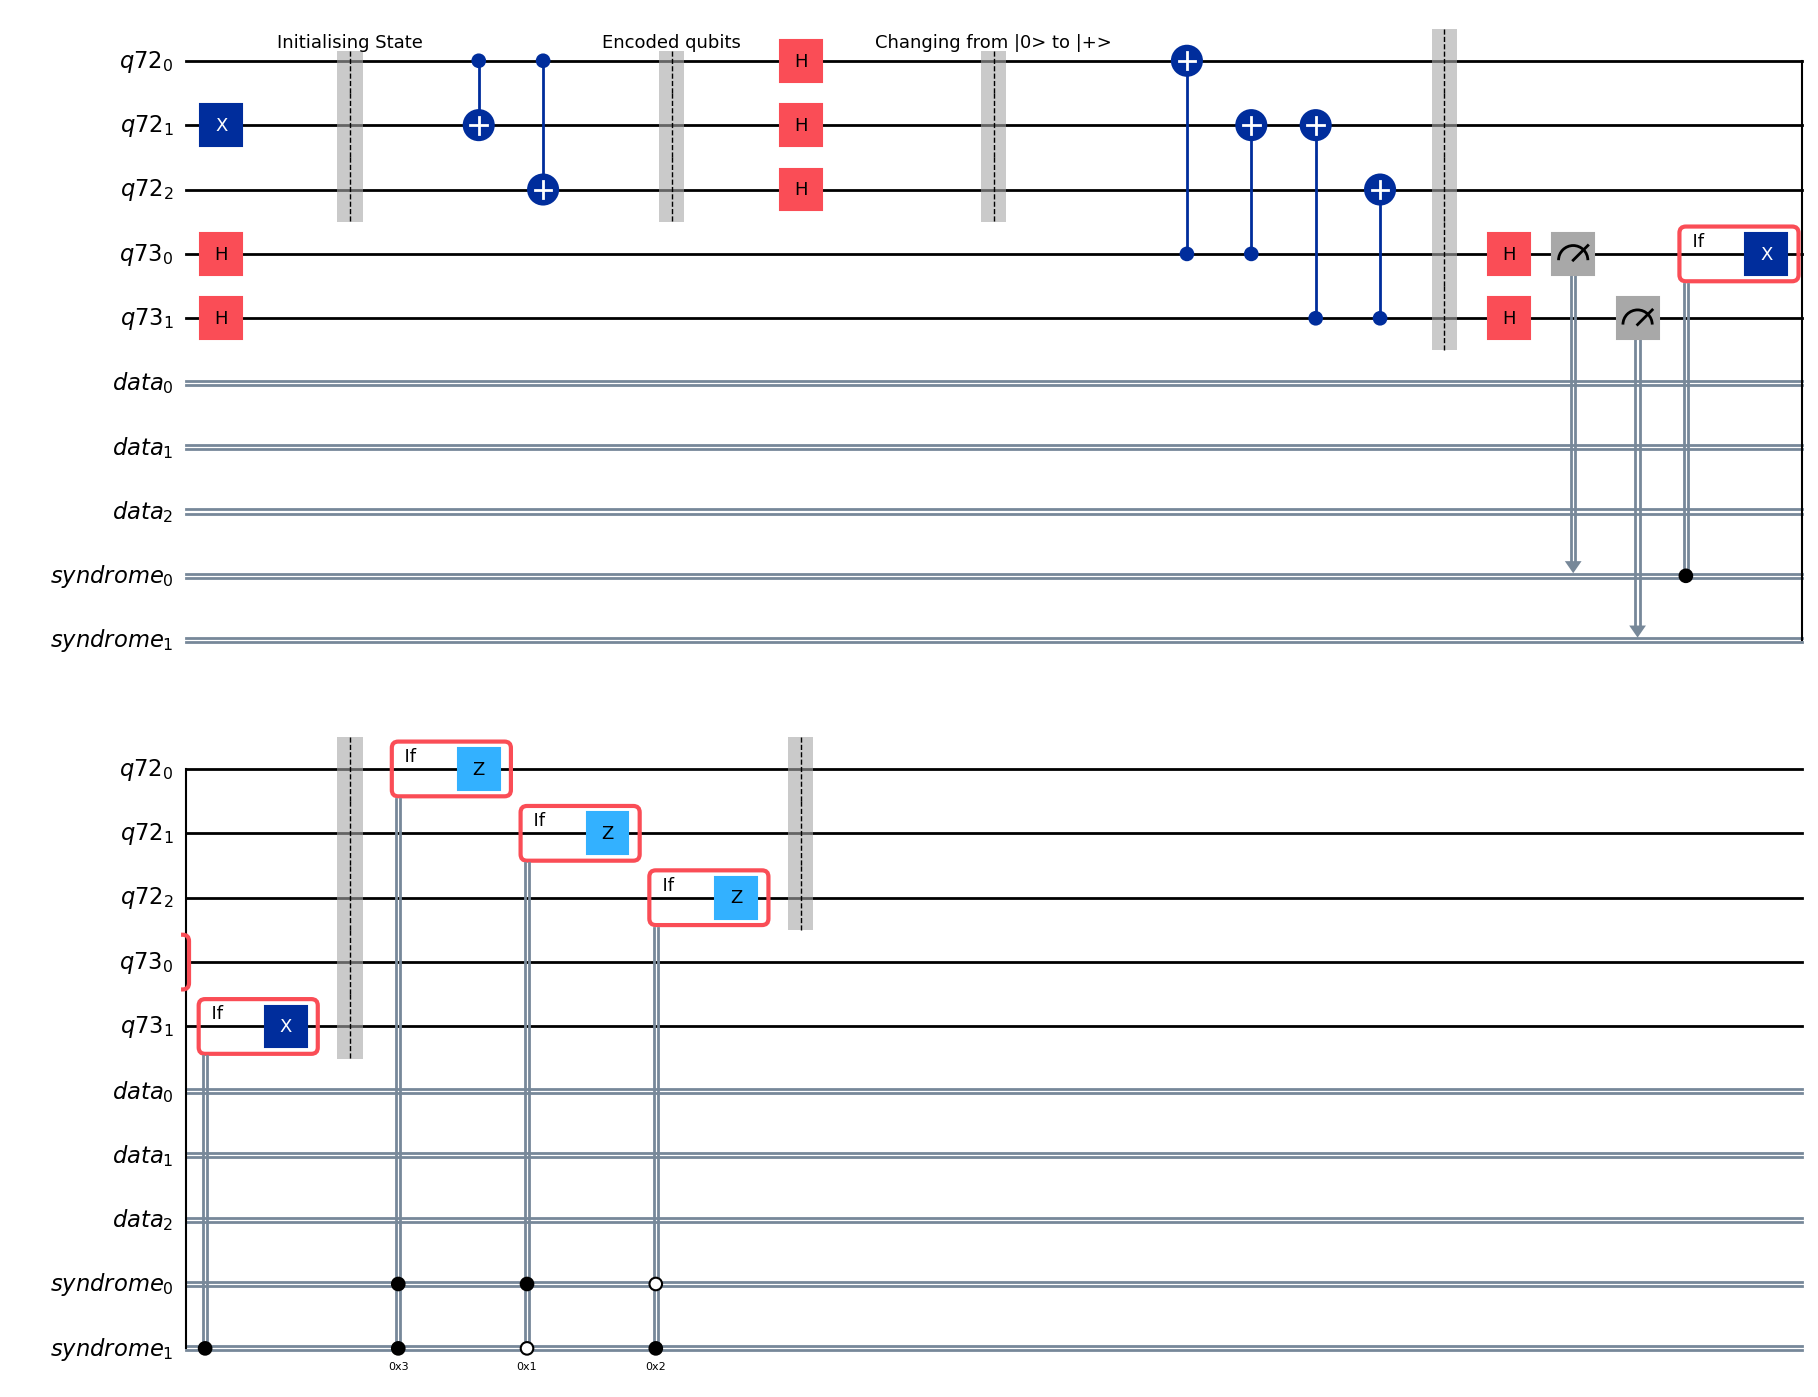

In [ ]:
def Correction_protocol(circuit: QuantumCircuit):
    with circuit.if_test((creg_syndrome, 3)):
        circuit.z(qreg_data[0])
    with circuit.if_test((creg_syndrome, 1)):
        circuit.z(qreg_data[1])
    with circuit.if_test((creg_syndrome, 2)):
        circuit.z(qreg_data[2])
    circuit.barrier(qreg_data)
    return circuit


def build_circuit(apply_correction: bool):
    circuit = build_qc()
    circuit = cx_encode(circuit, state_data, ancillas_data)
    circuit = measure(circuit)
    if apply_correction:
        circuit = Correction_protocol(circuit)

    return circuit

circuit = build_circuit(True)
circuit.draw(output="mpl", style="iqp", cregbundle=False)